# Dorschky 2020 — IMU Gait Tracking Dataset Overview

This notebook explores the experimental IMU and biomechanics data from the Dorschky 2020 dataset used in the BioSYM IMU-only gait tracking demo.
The dataset includes **10 subjects** × **6 trial conditions** (slow/normal/fast walking/running), with 100-node gait-cycle-averaged:
- Joint angles (hip, knee, ankle — right limb)
- Joint moments
- Ground reaction forces (GRF)
- IMU proper accelerations & angular velocities (7 body segments × 3 axes × 2 signal types)

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
DARK_BG   = '#0f1117'
PANEL_BG  = '#1a1e2e'
ACCENT1   = '#7c6af7'   # violet
ACCENT2   = '#f7826a'   # coral
ACCENT3   = '#4fc4cf'   # teal
ACCENT4   = '#f0c060'   # amber
ACCENT5   = '#84e08a'   # mint
TEXT_COL  = '#e8eaf6'
GRID_COL  = '#2a2f45'

plt.rcParams.update({
    'figure.facecolor':    DARK_BG,
    'axes.facecolor':      PANEL_BG,
    'axes.edgecolor':      GRID_COL,
    'axes.labelcolor':     TEXT_COL,
    'axes.titlecolor':     TEXT_COL,
    'axes.titlesize':      12,
    'axes.labelsize':      10,
    'xtick.color':         TEXT_COL,
    'ytick.color':         TEXT_COL,
    'xtick.labelsize':     8.5,
    'ytick.labelsize':     8.5,
    'grid.color':          GRID_COL,
    'grid.linewidth':      0.6,
    'legend.facecolor':    PANEL_BG,
    'legend.edgecolor':    GRID_COL,
    'legend.labelcolor':   TEXT_COL,
    'legend.fontsize':     8.5,
    'text.color':          TEXT_COL,
    'font.family':         'DejaVu Sans',
    'figure.dpi':          120,
})

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'dorschky2020trackingdata')
SUBJECTS  = [f'P{i:02d}' for i in range(1, 11)]
TRIALS    = ['slowwalking', 'normwalking', 'fastwalking', 'slowrunning', 'normrunning', 'fastrunning']
TRIAL_LABELS = ['Slow\nWalking', 'Normal\nWalking', 'Fast\nWalking', 'Slow\nRunning', 'Normal\nRunning', 'Fast\nRunning']

SEGMENTS = ['pelvis', 'femur_r', 'tibia_r', 'foot_r', 'femur_l', 'tibia_l', 'foot_l']
SEG_LABELS = ['Pelvis', 'Femur R', 'Tibia R', 'Foot R', 'Femur L', 'Tibia L', 'Foot L']

PHASE = np.linspace(0, 100, 100)   # % of gait cycle

print('✓  Setup complete — data directory:', DATA_DIR)

✓  Setup complete — data directory: /Users/markusgambietz/PhD/01_Python_Projects/biosym/dorschky_demo/dorschky2020trackingdata


In [2]:
# ── Helper: load a single parquet ────────────────────────────────────────────
def load_parquet(subject, trial):
    path = os.path.join(DATA_DIR, f'{subject}_{trial}_mean_FP.mat.parquet')
    if not os.path.exists(path):
        return None
    return pd.read_parquet(path)

def get_scalar(df, type_name):
    return float(df[df['type'] == type_name].iloc[0]['mean'][0])

def get_signal(df, type_name, name):
    """Returns (mean, var) arrays of shape (100,) for a named 1-D signal."""
    rows = df[(df['type'] == type_name) & (df['name'] == name)]
    m = np.array(rows.iloc[0]['mean'])
    v = np.array(rows.iloc[0]['var'])
    return m, np.maximum(v, 1e-5)

def get_sensor_xyz(df, type_name, seg):
    """Returns (mean, var) arrays of shape (3, 100) for acc or gyro."""
    rows = df[(df['type'] == type_name) & (df['name'] == seg)]
    mean = np.stack([np.array(r['mean']) for _, r in rows.iterrows()])
    var  = np.stack([np.array(r['var'])  for _, r in rows.iterrows()])
    return mean, np.maximum(var, 1e-5)

# Prefetch metadata for all subjects × normwalking for convenience
meta = {}
for s in SUBJECTS:
    for t in TRIALS:
        df = load_parquet(s, t)
        if df is not None:
            meta[(s, t)] = {
                'speed': get_scalar(df, 'speed'),
                'dur':   get_scalar(df, 'dur'),
            }

print(f'✓  Loaded metadata for {len(meta)} subject × trial combinations.')

✓  Loaded metadata for 60 subject × trial combinations.


---
## 1 · Gait Speed & Cycle Duration — All Subjects × All Conditions

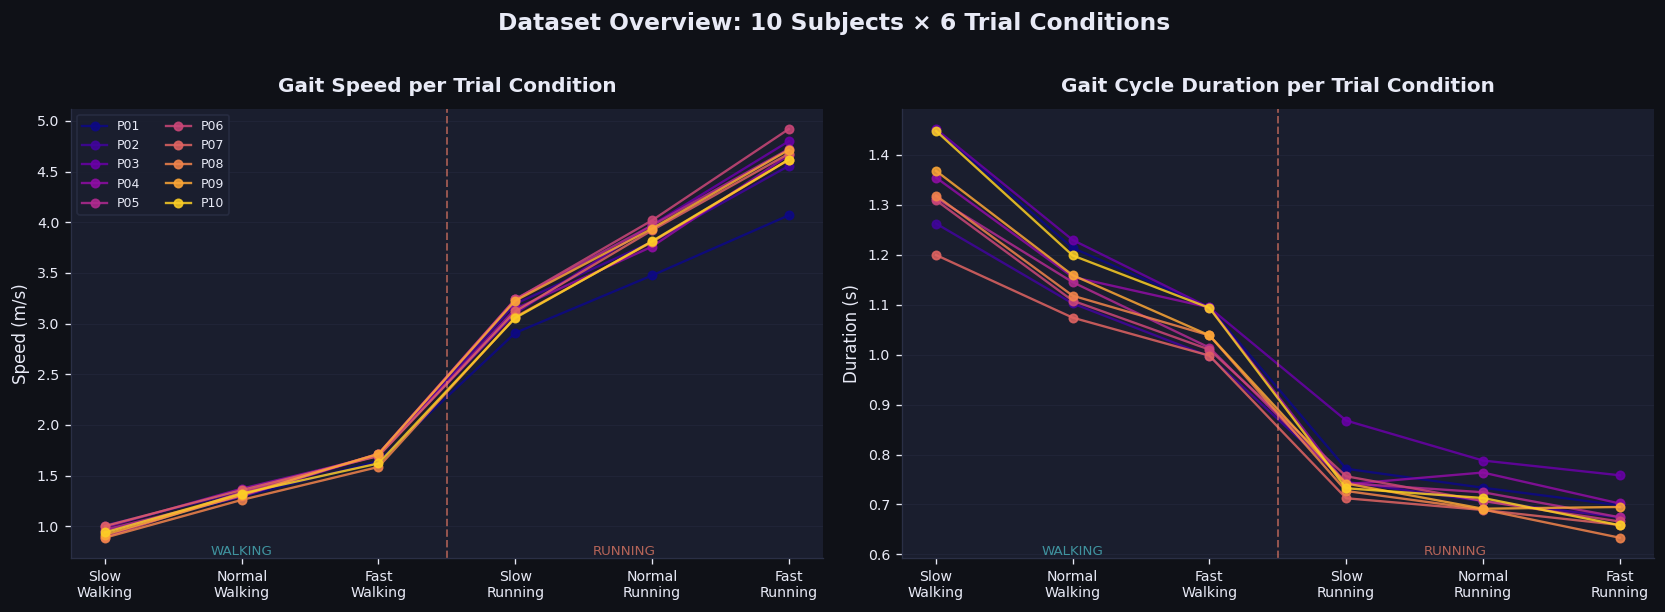

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

colors = [ACCENT1, ACCENT3, ACCENT2, '#a070f0', ACCENT4, ACCENT5]

for ax in axes:
    ax.set_facecolor(PANEL_BG)
    ax.grid(axis='y', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

x = np.arange(len(TRIALS))
width = 0.08
offsets = np.linspace(-(len(SUBJECTS)-1)/2, (len(SUBJECTS)-1)/2, len(SUBJECTS)) * width

for i, s in enumerate(SUBJECTS):
    speeds = [meta.get((s, t), {}).get('speed', np.nan) for t in TRIALS]
    durs   = [meta.get((s, t), {}).get('dur',   np.nan) for t in TRIALS]
    col = plt.cm.plasma(i / len(SUBJECTS))

    axes[0].plot(x, speeds, 'o-', color=col, lw=1.4, ms=5, label=s, alpha=0.85)
    axes[1].plot(x, durs,   'o-', color=col, lw=1.4, ms=5, label=s, alpha=0.85)

for ax, ylabel, title in zip(
        axes,
        ['Speed (m/s)', 'Duration (s)'],
        ['Gait Speed per Trial Condition', 'Gait Cycle Duration per Trial Condition']
):
    ax.set_xticks(x)
    ax.set_xticklabels(TRIAL_LABELS, fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=10)

axes[0].legend(ncol=2, fontsize=7.5, loc='upper left')

# Running / walking separator
for ax in axes:
    ax.axvline(2.5, color=ACCENT2, lw=1.2, ls='--', alpha=0.55)
    ax.text(1.0,  ax.get_ylim()[0], 'WALKING', color=ACCENT3, fontsize=8, ha='center', va='bottom', alpha=0.7)
    ax.text(3.8,  ax.get_ylim()[0], 'RUNNING', color=ACCENT2, fontsize=8, ha='center', va='bottom', alpha=0.7)

fig.suptitle('Dataset Overview: 10 Subjects × 6 Trial Conditions',
             fontsize=14, fontweight='bold', color=TEXT_COL, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · Right-Limb Joint Angles — Mean ± 1σ Across All Subjects

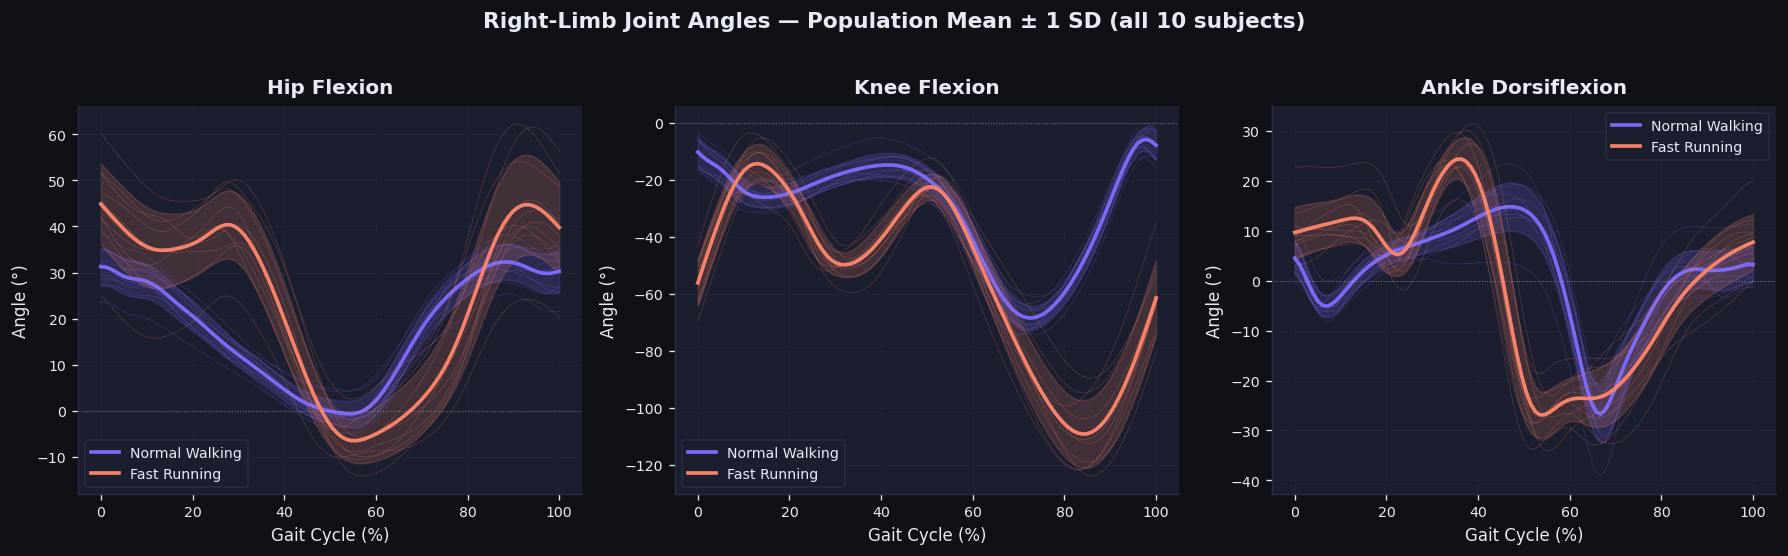

In [4]:
joint_names  = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']
joint_labels = ['Hip Flexion', 'Knee Flexion', 'Ankle Dorsiflexion']
trial_sel    = ['normwalking', 'fastrunning']
trial_colors = [ACCENT1, ACCENT2]
trial_lbls   = ['Normal Walking', 'Fast Running']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig.patch.set_facecolor(DARK_BG)

for ax, jname, jlabel in zip(axes, joint_names, joint_labels):
    ax.set_facecolor(PANEL_BG)
    ax.grid(alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Gait Cycle (%)')
    ax.set_ylabel('Angle (°)')
    ax.set_title(jlabel, fontweight='bold', pad=8)

    for trial, color, tlabel in zip(trial_sel, trial_colors, trial_lbls):
        all_means = []
        for s in SUBJECTS:
            df = load_parquet(s, trial)
            if df is None:
                continue
            m, _ = get_signal(df, 'angle', jname)
            all_means.append(np.rad2deg(m))

        arr = np.array(all_means)           # (n_subjects, 100)
        pop_mean = arr.mean(axis=0)
        pop_std  = arr.std(axis=0)

        ax.plot(PHASE, pop_mean, color=color, lw=2.2, label=tlabel)
        ax.fill_between(PHASE, pop_mean - pop_std, pop_mean + pop_std,
                        color=color, alpha=0.18)

        # Individual subject traces (light)
        for m_ind in all_means:
            ax.plot(PHASE, m_ind, color=color, lw=0.45, alpha=0.25)

    ax.axhline(0, color=TEXT_COL, lw=0.6, ls=':', alpha=0.4)
    ax.legend()

fig.suptitle('Right-Limb Joint Angles — Population Mean ± 1 SD (all 10 subjects)',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · IMU Proper Accelerations — Mean Signal with Uncertainty Band
### Subject P02, Normal Walking — all 7 body segments, X / Y / Z axes

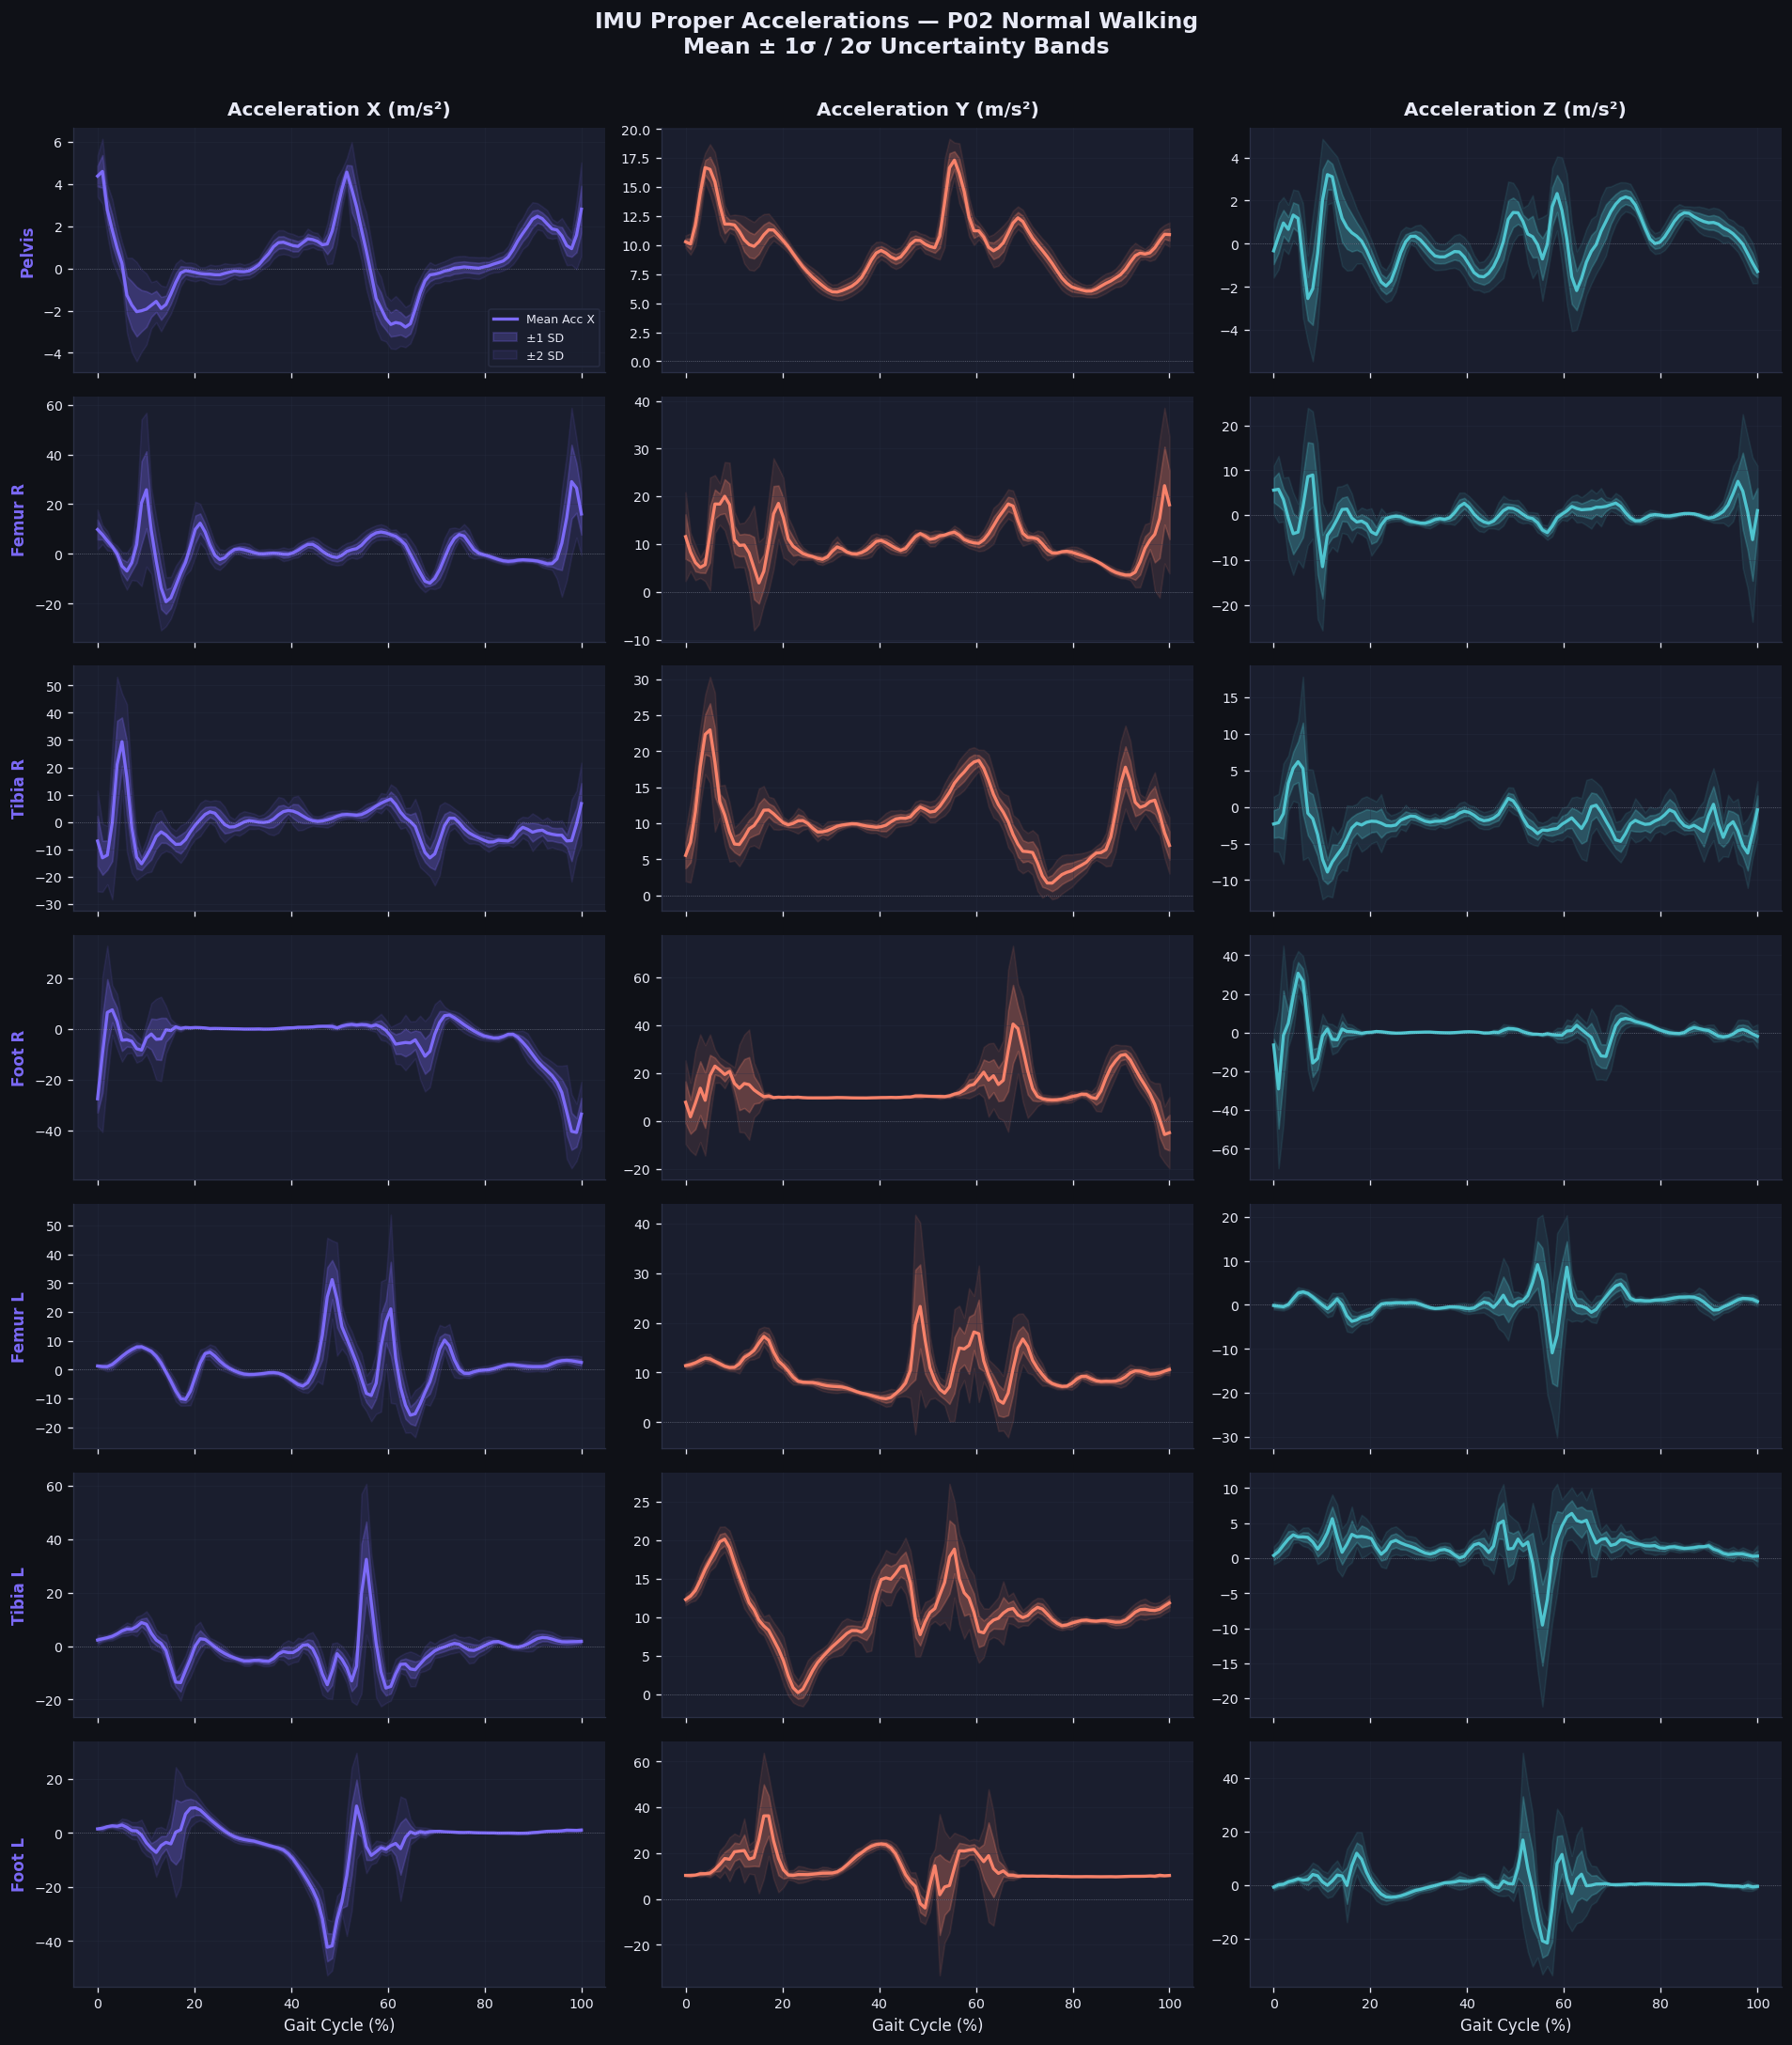

np.float64(0.004053976869291806)

In [7]:
SUBJECT = 'P02'
TRIAL   = 'normwalking'
df_ref  = load_parquet(SUBJECT, TRIAL)

axis_colors = [ACCENT1, ACCENT2, ACCENT3]
axis_labels = ['X', 'Y', 'Z']

fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(16, 18), sharex=True)
fig.patch.set_facecolor(DARK_BG)

for row, (seg, seg_label) in enumerate(zip(SEGMENTS, SEG_LABELS)):
    acc_mean, acc_var = get_sensor_xyz(df_ref, 'acc', seg)
    acc_std = np.sqrt(acc_var)

    for col in range(3):
        ax = axes[row, col]
        ax.set_facecolor(PANEL_BG)
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

        m = acc_mean[col]
        s = acc_std[col]
        c = axis_colors[col]

        ax.plot(PHASE, m, color=c, lw=2, label=f'Mean Acc {axis_labels[col]}')
        ax.fill_between(PHASE, m - s, m + s, color=c, alpha=0.25, label='±1 SD')
        ax.fill_between(PHASE, m - 2*s, m + 2*s, color=c, alpha=0.10, label='±2 SD')
        ax.axhline(0, color=TEXT_COL, lw=0.5, ls=':', alpha=0.35)

        if row == 0:
            ax.set_title(f'Acceleration {axis_labels[col]} (m/s²)', fontweight='bold', pad=8)
        if col == 0:
            ax.set_ylabel(seg_label, fontsize=10, fontweight='bold', color=c)
        if row == len(SEGMENTS) - 1:
            ax.set_xlabel('Gait Cycle (%)')

        if row == 0 and col == 0:
            ax.legend(fontsize=7.5)

fig.suptitle(f'IMU Proper Accelerations — {SUBJECT} Normal Walking\nMean ± 1σ / 2σ Uncertainty Bands',
             fontsize=14, fontweight='bold', color=TEXT_COL, y=1.005)
plt.tight_layout()
plt.show()
acc_var.min()

---
## 4 · IMU Angular Velocities — Mean Signal with Uncertainty Band

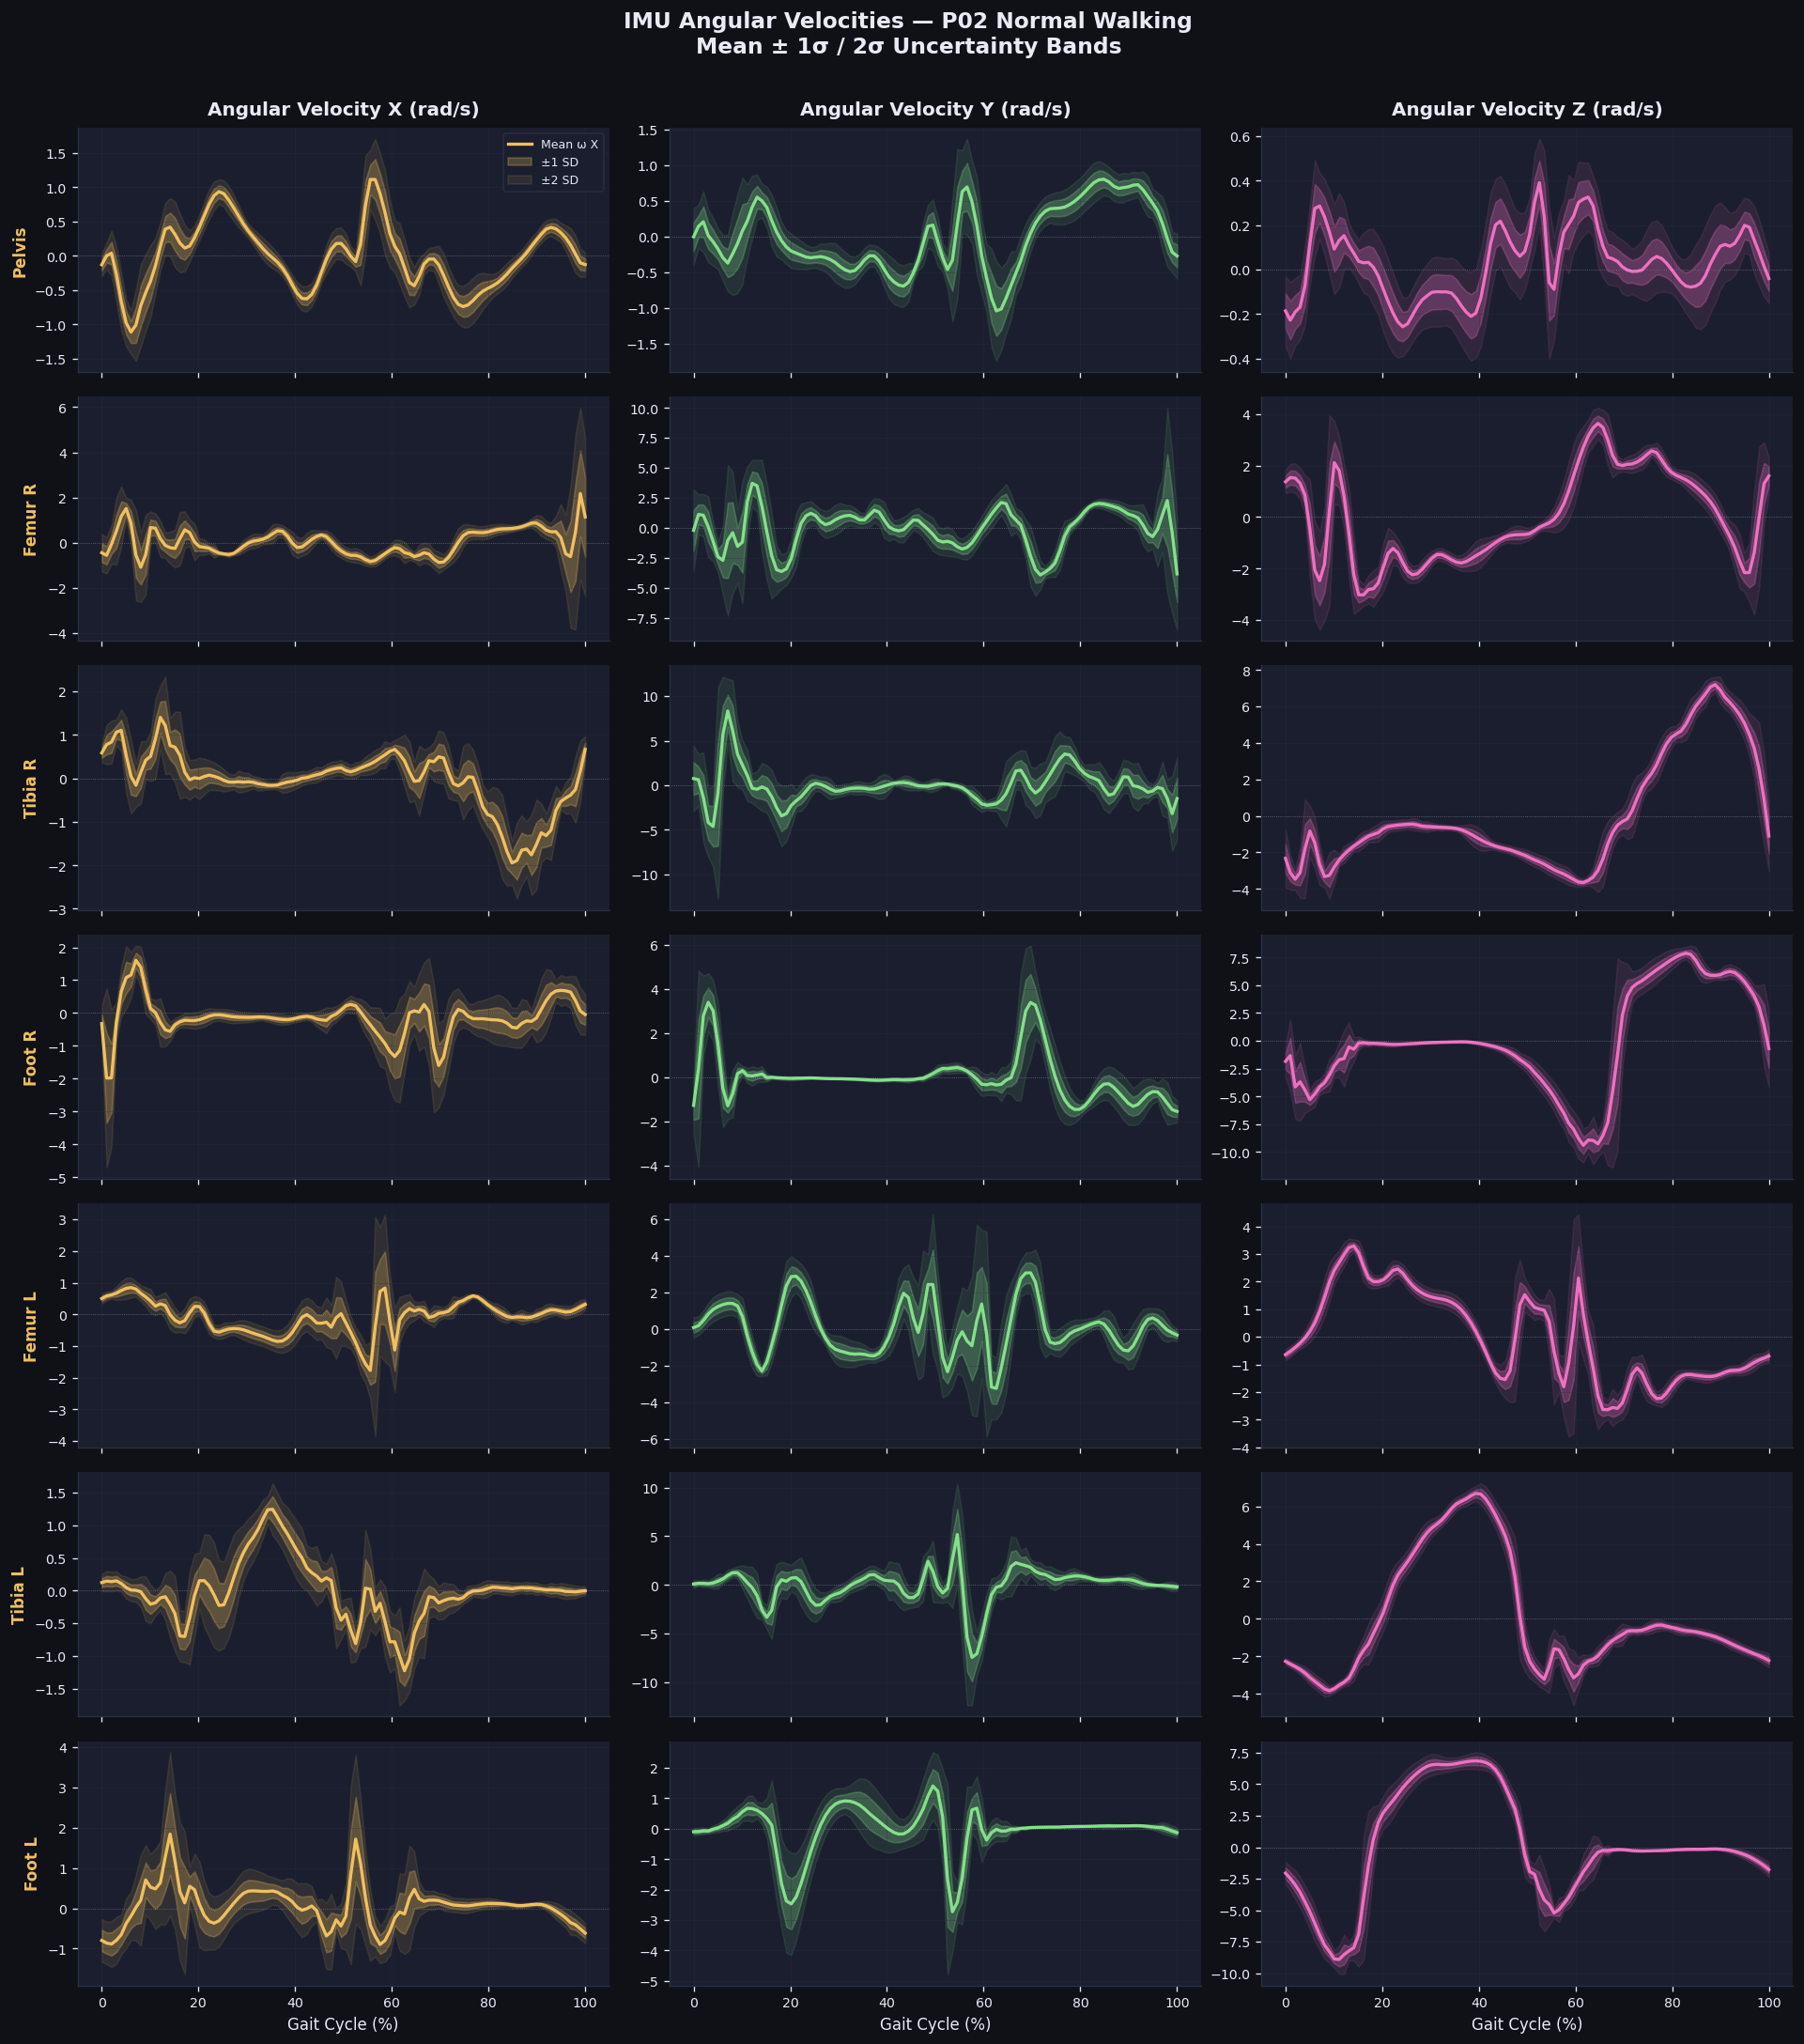

np.float64(8.422833001869672e-05)

In [8]:
axis_colors = [ACCENT4, ACCENT5, '#f070c0']   # amber, mint, pink for gyro

fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(16, 18), sharex=True)
fig.patch.set_facecolor(DARK_BG)

for row, (seg, seg_label) in enumerate(zip(SEGMENTS, SEG_LABELS)):
    gyr_mean, gyr_var = get_sensor_xyz(df_ref, 'gyro', seg)
    gyr_std = np.sqrt(gyr_var)

    for col in range(3):
        ax = axes[row, col]
        ax.set_facecolor(PANEL_BG)
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

        m = gyr_mean[col]
        s = gyr_std[col]
        c = axis_colors[col]

        ax.plot(PHASE, m, color=c, lw=2, label=f'Mean ω {axis_labels[col]}')
        ax.fill_between(PHASE, m - s, m + s, color=c, alpha=0.25, label='±1 SD')
        ax.fill_between(PHASE, m - 2*s, m + 2*s, color=c, alpha=0.10, label='±2 SD')
        ax.axhline(0, color=TEXT_COL, lw=0.5, ls=':', alpha=0.35)

        if row == 0:
            ax.set_title(f'Angular Velocity {axis_labels[col]} (rad/s)', fontweight='bold', pad=8)
        if col == 0:
            ax.set_ylabel(seg_label, fontsize=10, fontweight='bold', color=c)
        if row == len(SEGMENTS) - 1:
            ax.set_xlabel('Gait Cycle (%)')
        if row == 0 and col == 0:
            ax.legend(fontsize=7.5)

fig.suptitle(f'IMU Angular Velocities — {SUBJECT} Normal Walking\nMean ± 1σ / 2σ Uncertainty Bands',
             fontsize=14, fontweight='bold', color=TEXT_COL, y=1.005)
plt.tight_layout()
plt.show()
gyr_var.min()

---
## 5 · IMU Signal Variance Heatmap — All Segments & Axes
### How uncertain is each channel, normalised by its mean magnitude?

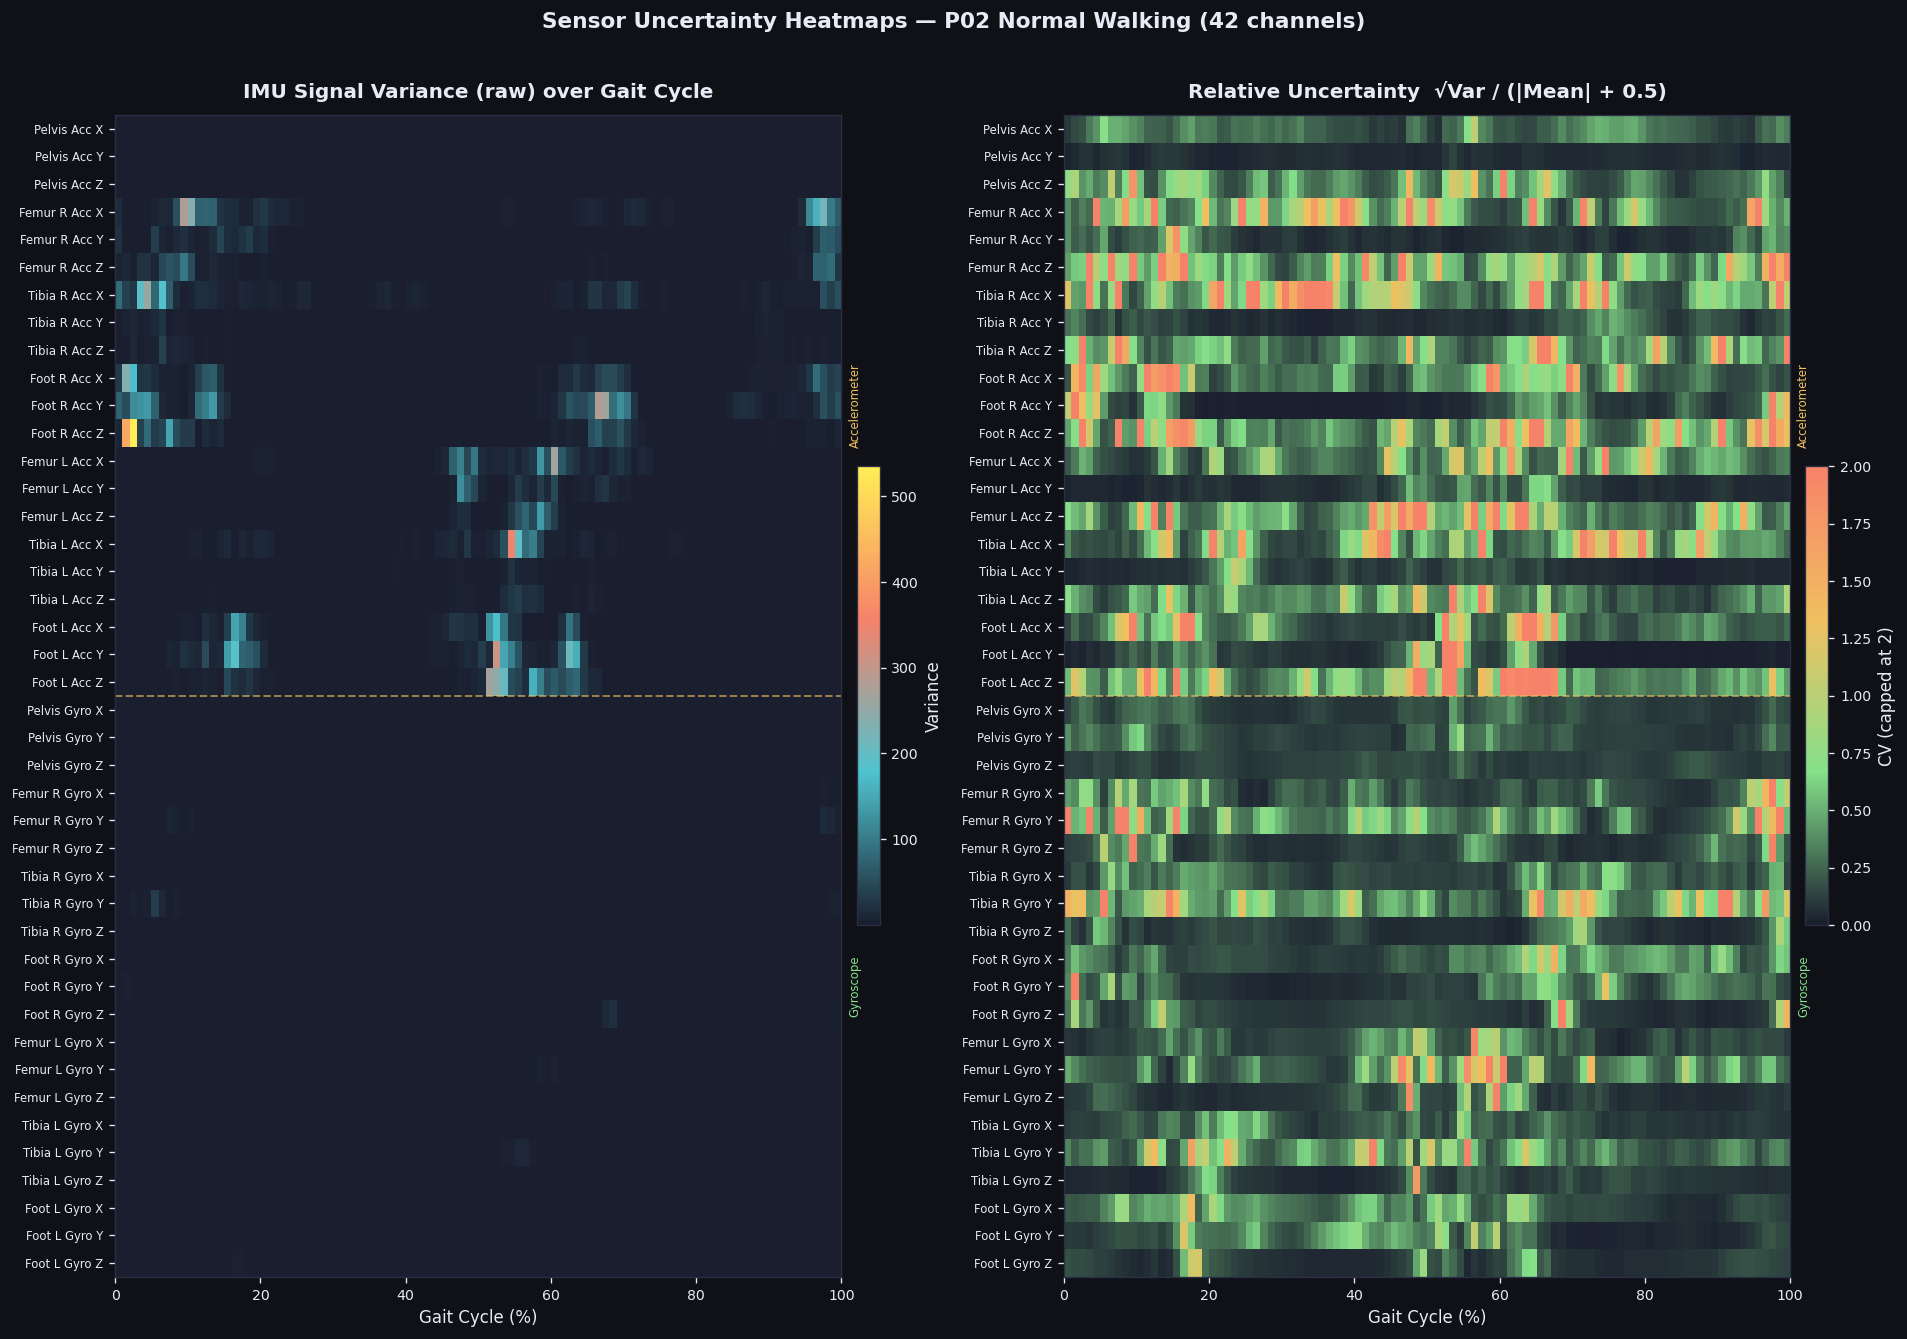

In [9]:
sensor_types = ['acc', 'gyro']
type_units   = ['m/s²', 'rad/s']
axes_lbl     = ['X', 'Y', 'Z']

# Build (channels × 100) arrays for mean and var
channel_labels = []
mean_mat = []
var_mat  = []

for stype in sensor_types:
    for seg, slbl in zip(SEGMENTS, SEG_LABELS):
        m, v = get_sensor_xyz(df_ref, stype, seg)
        for ax_i, ax_l in enumerate(axes_lbl):
            channel_labels.append(f'{slbl} {stype.capitalize()} {ax_l}')
            mean_mat.append(m[ax_i])
            var_mat.append(v[ax_i])

mean_mat = np.array(mean_mat)   # (42, 100)
var_mat  = np.array(var_mat)    # (42, 100)

# Coefficient of variation-like metric: sqrt(var) / (|mean| + epsilon)
cv_mat = np.sqrt(var_mat) / (np.abs(mean_mat) + 0.5)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 11), gridspec_kw={'width_ratios': [1, 1]})
fig.patch.set_facecolor(DARK_BG)

cmap_var = LinearSegmentedColormap.from_list('var_cmap', ['#1a1e2e', '#4fc4cf', '#f7826a', '#ffee55'])
cmap_cv  = LinearSegmentedColormap.from_list('cv_cmap',  ['#1a1e2e', '#84e08a', '#f0c060', '#f7826a'])

# Panel 1: raw variance
im0 = axes[0].imshow(var_mat, aspect='auto', cmap=cmap_var,
                     extent=[0, 100, len(channel_labels)-0.5, -0.5])
axes[0].set_title('IMU Signal Variance (raw) over Gait Cycle', fontweight='bold', pad=10)
axes[0].set_xlabel('Gait Cycle (%)')
axes[0].set_yticks(range(len(channel_labels)))
axes[0].set_yticklabels(channel_labels, fontsize=7)
plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02, label='Variance')

# Panel 2: relative uncertainty (CV)
im1 = axes[1].imshow(cv_mat, aspect='auto', cmap=cmap_cv,
                     extent=[0, 100, len(channel_labels)-0.5, -0.5],
                     vmin=0, vmax=2)
axes[1].set_title('Relative Uncertainty  √Var / (|Mean| + 0.5)', fontweight='bold', pad=10)
axes[1].set_xlabel('Gait Cycle (%)')
axes[1].set_yticks(range(len(channel_labels)))
axes[1].set_yticklabels(channel_labels, fontsize=7)
plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02, label='CV (capped at 2)')

# Separator lines between sensor types
for ax in axes:
    ax.axhline(20.5, color=ACCENT4, lw=1.2, ls='--', alpha=0.6)
    ax.text(101, 10, 'Accelerometer', color=ACCENT4, fontsize=7, va='center',
            rotation=90, ha='left')
    ax.text(101, 31, 'Gyroscope', color=ACCENT5, fontsize=7, va='center',
            rotation=90, ha='left')

fig.suptitle(f'Sensor Uncertainty Heatmaps — {SUBJECT} Normal Walking (42 channels)',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Walking vs. Running Comparison — Key IMU Channels
### Tibia R (longitudinal acc) and Pelvis (vertical acc) across trial conditions

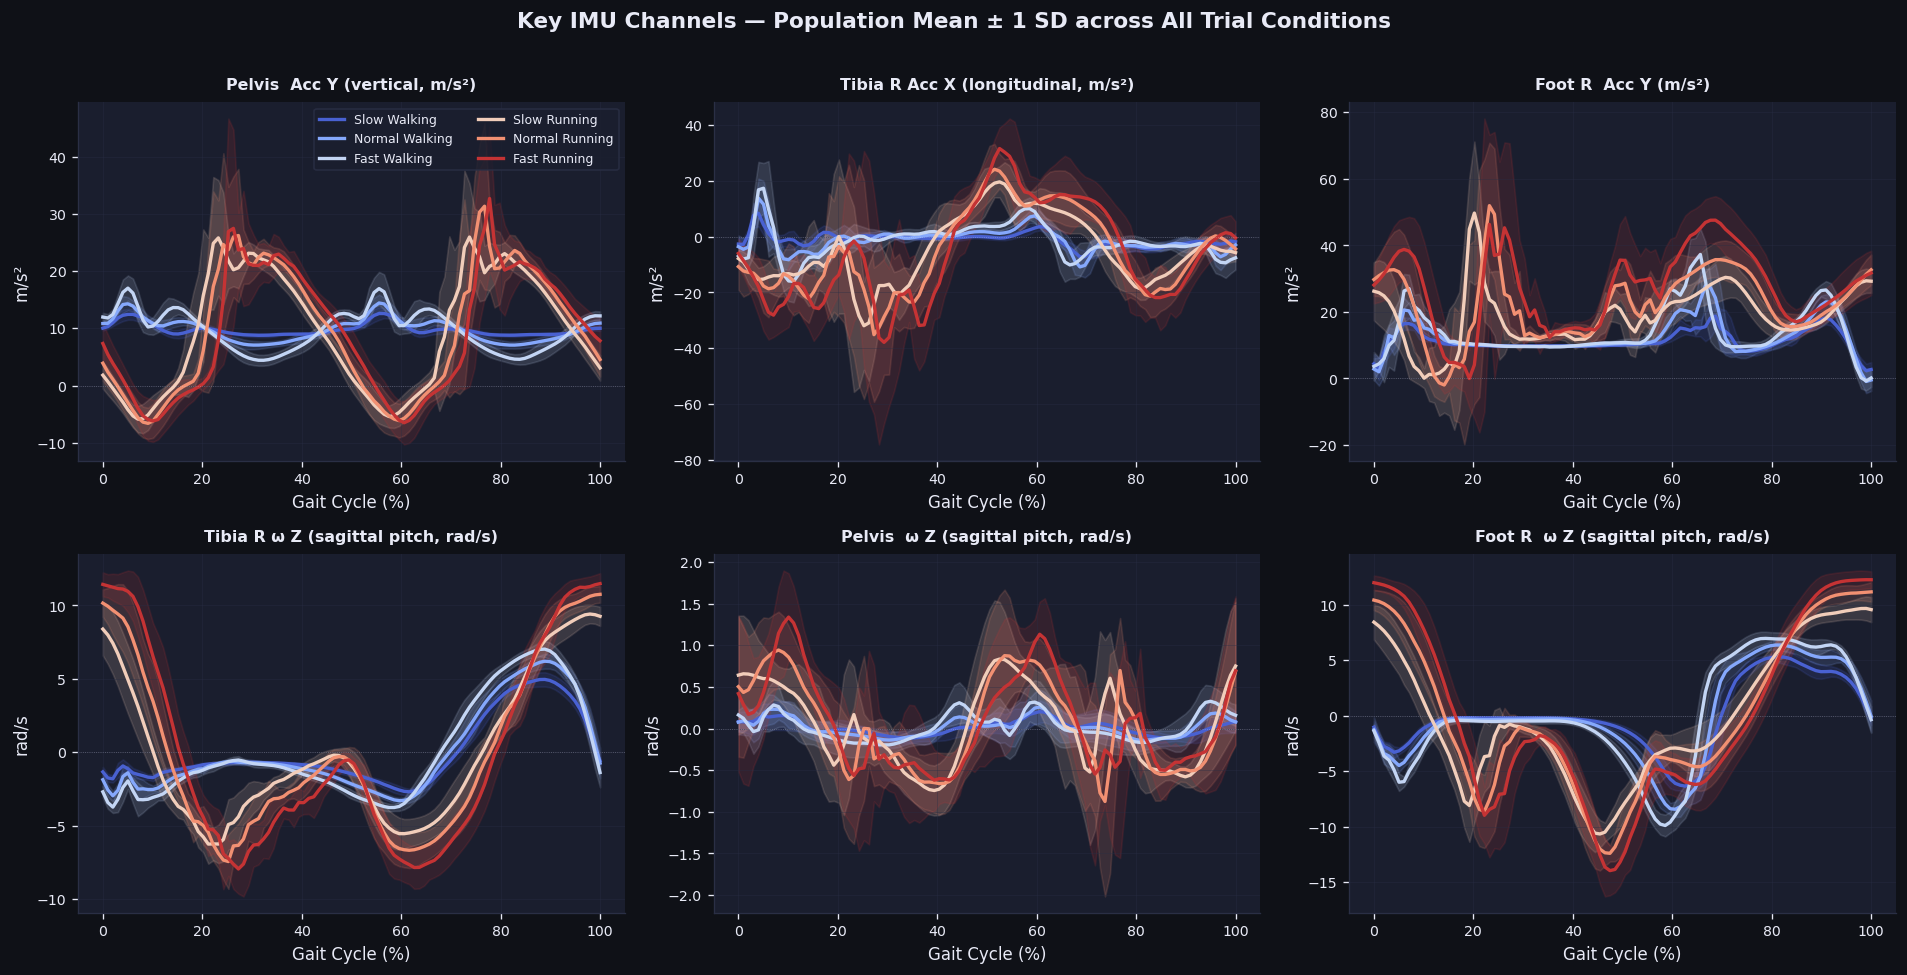

In [10]:
# Colour ramp over trials (blue → red)
trial_colors6 = plt.cm.coolwarm(np.linspace(0.05, 0.95, 6))

# Channels to show: (type, seg, axis_idx, label, unit)
channels = [
    ('acc',  'pelvis',   1, 'Pelvis  Acc Y (vertical, m/s²)',          'm/s²'),
    ('acc',  'tibia_r',  0, 'Tibia R Acc X (longitudinal, m/s²)',       'm/s²'),
    ('acc',  'foot_r',   1, 'Foot R  Acc Y (m/s²)',                     'm/s²'),
    ('gyro', 'tibia_r',  2, 'Tibia R ω Z (sagittal pitch, rad/s)',       'rad/s'),
    ('gyro', 'pelvis',   2, 'Pelvis  ω Z (sagittal pitch, rad/s)',       'rad/s'),
    ('gyro', 'foot_r',   2, 'Foot R  ω Z (sagittal pitch, rad/s)',       'rad/s'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(DARK_BG)

for ax, (stype, seg, ax_idx, lbl, unit) in zip(axes.flat, channels):
    ax.set_facecolor(PANEL_BG)
    ax.grid(alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Gait Cycle (%)')
    ax.set_ylabel(unit)
    ax.set_title(lbl, fontweight='bold', pad=8, fontsize=9.5)

    for trial, color, tlbl in zip(TRIALS, trial_colors6, TRIAL_LABELS):
        all_means = []
        for s in SUBJECTS:
            df = load_parquet(s, trial)
            if df is None:
                continue
            m, _ = get_sensor_xyz(df, stype, seg)
            all_means.append(m[ax_idx])

        arr = np.array(all_means)
        pop_mean = arr.mean(axis=0)
        pop_std  = arr.std(axis=0)

        ax.plot(PHASE, pop_mean, color=color, lw=2.0,
                label=tlbl.replace('\n', ' '))
        ax.fill_between(PHASE, pop_mean - pop_std, pop_mean + pop_std,
                        color=color, alpha=0.15)

    ax.axhline(0, color=TEXT_COL, lw=0.5, ls=':', alpha=0.35)

axes.flat[0].legend(fontsize=7.5, ncol=2, loc='upper right')

fig.suptitle('Key IMU Channels — Population Mean ± 1 SD across All Trial Conditions',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.01)
plt.tight_layout()
plt.show()

---
## 7 · Ground Reaction Forces — Walking vs. Running
### Vertical and A/P GRF normalised by body weight

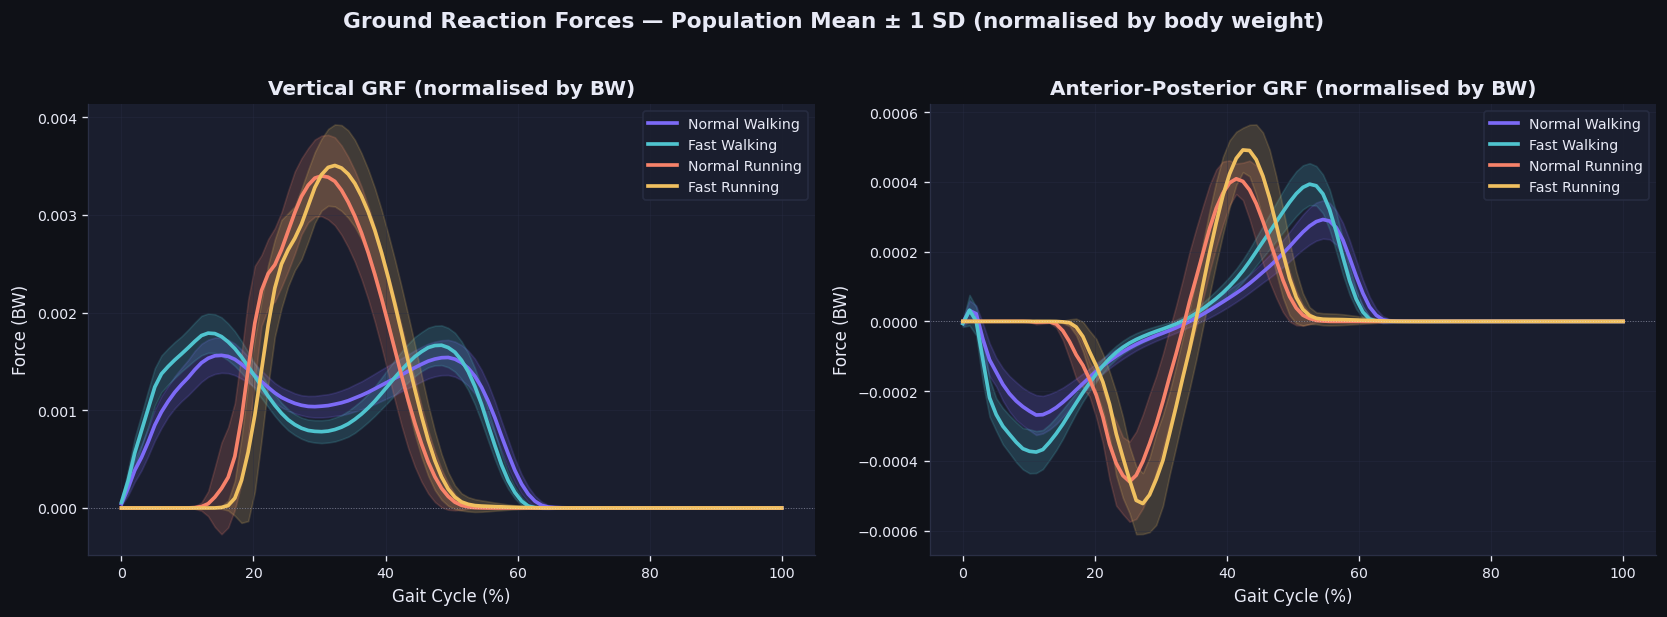

In [11]:
from pathlib import Path

info = pd.read_csv(Path(DATA_DIR) / 'ParticipantInfo.csv')
g = 9.81

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
for ax in axes:
    ax.set_facecolor(PANEL_BG)
    ax.grid(alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

grf_trials = [('normwalking', ACCENT1, 'Normal Walking'),
              ('fastwalking',  ACCENT3, 'Fast Walking'),
              ('normrunning',  ACCENT2, 'Normal Running'),
              ('fastrunning',  ACCENT4, 'Fast Running')]

for trial, color, label in grf_trials:
    vert_all, ap_all = [], []
    for s in SUBJECTS:
        df = load_parquet(s, trial)
        if df is None:
            continue
        mass = float(info[info['ID'] == s].iloc[0]['BODYMASS'])
        bw   = mass * g

        grf_x_m, _ = get_signal(df, 'GRF', 'GRF_x_r')
        grf_y_m, _ = get_signal(df, 'GRF', 'GRF_y_r')
        ap_all.append(grf_x_m / bw)
        vert_all.append(grf_y_m / bw)

    ap_arr   = np.array(ap_all)
    vert_arr = np.array(vert_all)

    axes[0].plot(PHASE, vert_arr.mean(0), color=color, lw=2.2, label=label)
    axes[0].fill_between(PHASE, vert_arr.mean(0)-vert_arr.std(0),
                         vert_arr.mean(0)+vert_arr.std(0), color=color, alpha=0.18)

    axes[1].plot(PHASE, ap_arr.mean(0),   color=color, lw=2.2, label=label)
    axes[1].fill_between(PHASE, ap_arr.mean(0)-ap_arr.std(0),
                         ap_arr.mean(0)+ap_arr.std(0),   color=color, alpha=0.18)

axes[0].set_title('Vertical GRF (normalised by BW)', fontweight='bold')
axes[1].set_title('Anterior-Posterior GRF (normalised by BW)', fontweight='bold')
for ax in axes:
    ax.set_xlabel('Gait Cycle (%)')
    ax.set_ylabel('Force (BW)')
    ax.axhline(0, color=TEXT_COL, lw=0.6, ls=':', alpha=0.4)
    ax.legend()

fig.suptitle('Ground Reaction Forces — Population Mean ± 1 SD (normalised by body weight)',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.02)
plt.tight_layout()
plt.show()

---
## 8 · Per-Subject IMU Magnitude Profile — Comparing Segments

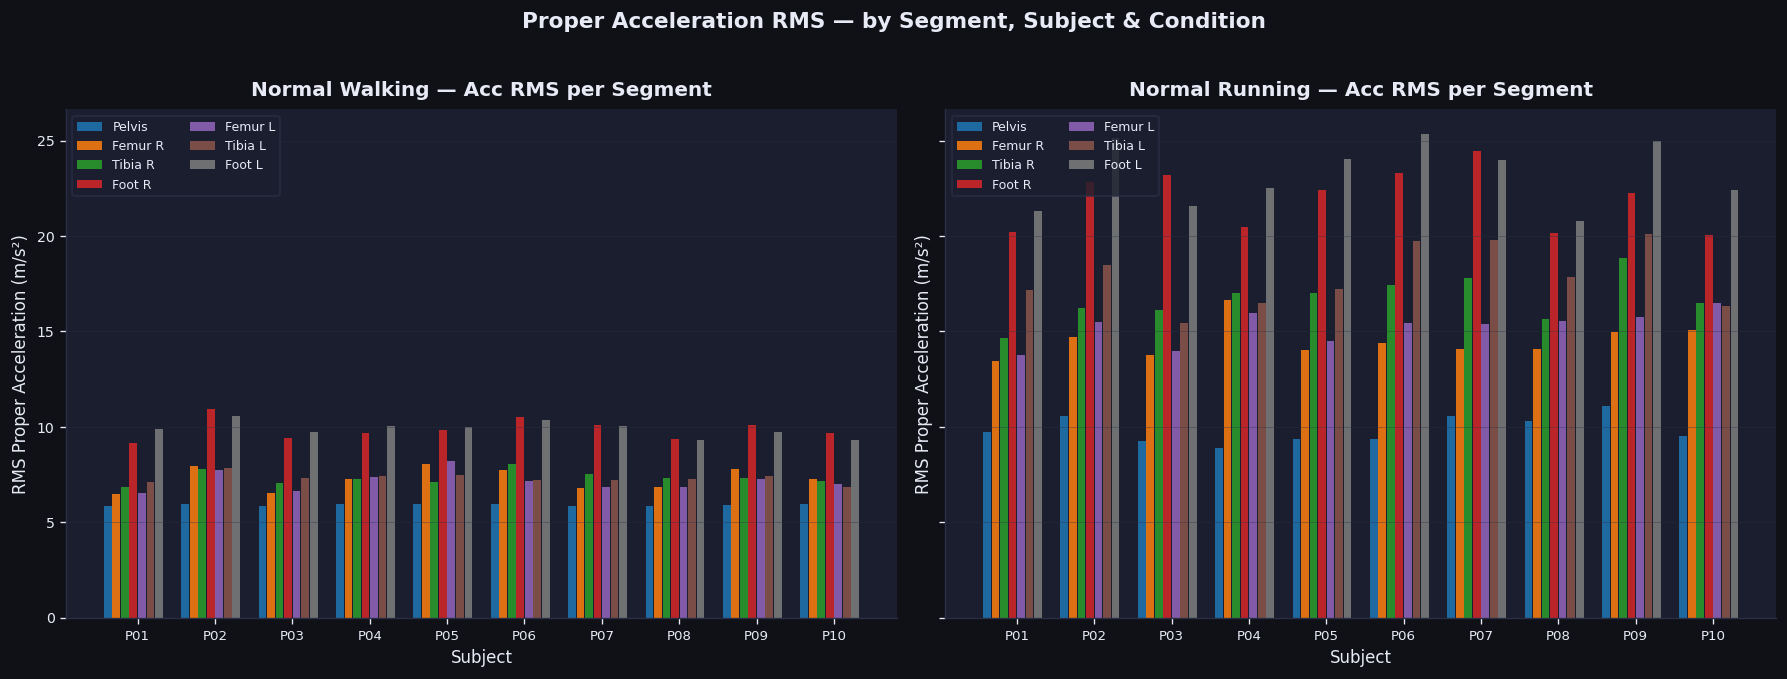

In [12]:
# RMS of proper acceleration magnitude per segment, per subject, per trial
trial_sel2 = ['normwalking', 'normrunning']
seg_colors = plt.cm.tab10(np.linspace(0, 0.7, len(SEGMENTS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
fig.patch.set_facecolor(DARK_BG)

for ax, trial, tlbl in zip(axes, trial_sel2, ['Normal Walking', 'Normal Running']):
    ax.set_facecolor(PANEL_BG)
    ax.grid(axis='y', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f'{tlbl} — Acc RMS per Segment', fontweight='bold', pad=8)
    ax.set_ylabel('RMS Proper Acceleration (m/s²)')
    ax.set_xlabel('Subject')
    ax.set_xticks(range(len(SUBJECTS)))
    ax.set_xticklabels(SUBJECTS, fontsize=8)

    for s_idx, (seg, slbl, col) in enumerate(zip(SEGMENTS, SEG_LABELS, seg_colors)):
        rms_vals = []
        for subj in SUBJECTS:
            df = load_parquet(subj, trial)
            if df is None:
                rms_vals.append(np.nan)
                continue
            m, _ = get_sensor_xyz(df, 'acc', seg)
            rms = np.sqrt(np.mean(m**2))
            rms_vals.append(rms)

        x = np.arange(len(SUBJECTS))
        offset = (s_idx - len(SEGMENTS)/2) * 0.11
        bars = ax.bar(x + offset, rms_vals, width=0.1, color=col,
                      label=slbl, alpha=0.85, edgecolor='none')

    ax.legend(fontsize=7.5, ncol=2, loc='upper left')

fig.suptitle('Proper Acceleration RMS — by Segment, Subject & Condition',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.02)
plt.tight_layout()
plt.show()

---
## 9 · IMU Sensor Variance — Channel-level Summary Box Plots
### Distribution of mean variance across the gait cycle and all 10 subjects

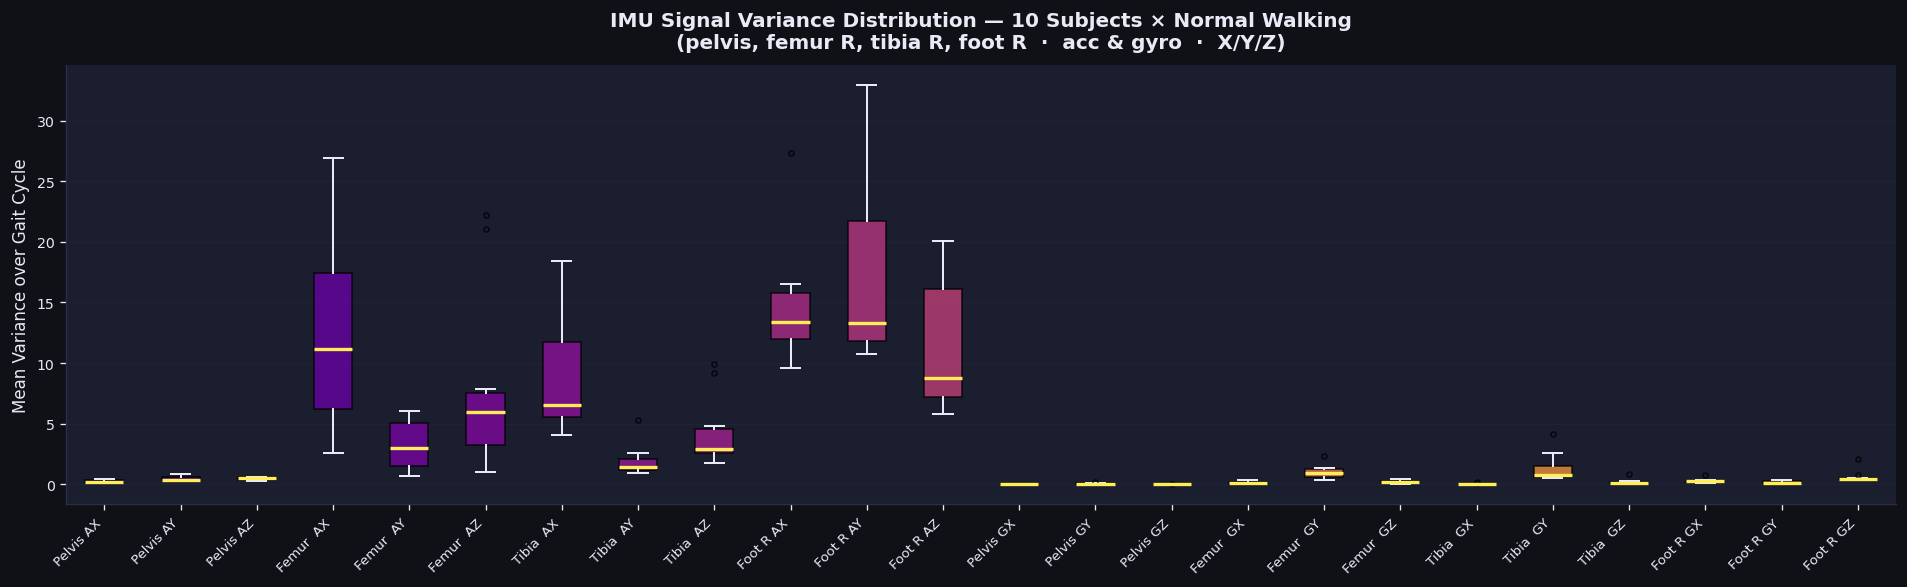

In [13]:
# For each (type, seg, axis) channel, collect mean variance across gait cycle for each subject
channel_names_short = []
var_data = {}   # channel_name -> list of 10 values (one per subject)

for stype, stype_short in [('acc', 'A'), ('gyro', 'G')]:
    for seg, slbl in zip(SEGMENTS[:4], SEG_LABELS[:4]):  # limit to right-side + pelvis for readability
        for ax_i, ax_l in enumerate(axes_lbl):
            cname = f'{slbl[:6]} {stype_short}{ax_l}'
            channel_names_short.append(cname)
            vals = []
            for s in SUBJECTS:
                df = load_parquet(s, 'normwalking')
                if df is None:
                    continue
                _, v = get_sensor_xyz(df, stype, seg)
                vals.append(np.mean(v[ax_i]))
            var_data[cname] = vals

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)
ax.grid(axis='y', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

bp = ax.boxplot(
    [var_data[c] for c in channel_names_short],
    patch_artist=True,
    medianprops=dict(color='#ffee55', lw=2),
    whiskerprops=dict(color=TEXT_COL, lw=1.2),
    capprops=dict(color=TEXT_COL, lw=1.2),
    flierprops=dict(marker='o', color=ACCENT2, markersize=3, alpha=0.7),
)

n = len(channel_names_short)
grad = plt.cm.plasma(np.linspace(0.1, 0.9, n))
for patch, color in zip(bp['boxes'], grad):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, n+1))
ax.set_xticklabels(channel_names_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Variance over Gait Cycle')
ax.set_title('IMU Signal Variance Distribution — 10 Subjects × Normal Walking\n'
             '(pelvis, femur R, tibia R, foot R  ·  acc & gyro  ·  X/Y/Z)',
             fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

---
## 10 · Phase-space Portrait — Tibia Sagittal Kinematics
### Acceleration vs. Angular Velocity for all subjects and conditions

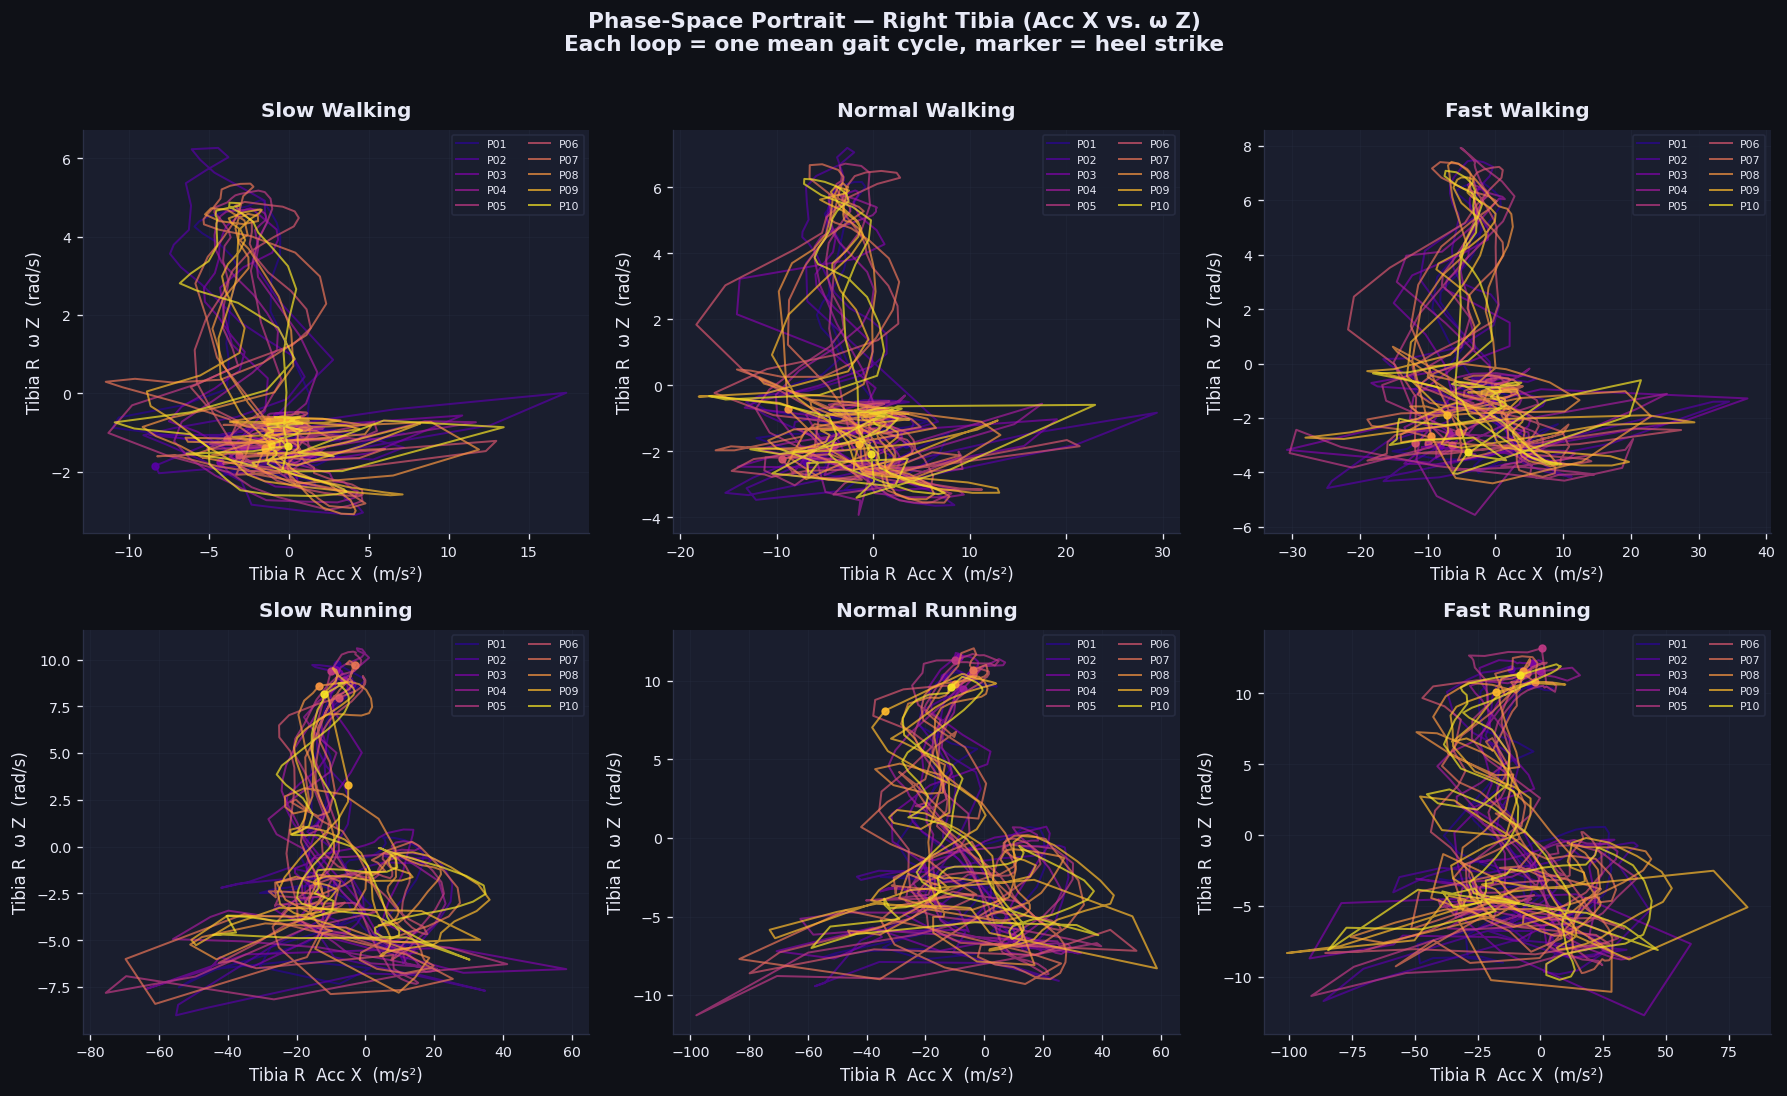

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(DARK_BG)

for ax, trial, tlbl in zip(axes.flat, TRIALS, TRIAL_LABELS):
    ax.set_facecolor(PANEL_BG)
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Tibia R  Acc X  (m/s²)')
    ax.set_ylabel('Tibia R  ω Z  (rad/s)')
    ax.set_title(tlbl.replace('\n', ' '), fontweight='bold', pad=8)

    subj_colors = plt.cm.plasma(np.linspace(0.05, 0.95, len(SUBJECTS)))
    for s, col in zip(SUBJECTS, subj_colors):
        df = load_parquet(s, trial)
        if df is None:
            continue
        acc_m, _ = get_sensor_xyz(df, 'acc',  'tibia_r')
        gyr_m, _ = get_sensor_xyz(df, 'gyro', 'tibia_r')

        # close the loop
        x = np.append(acc_m[0], acc_m[0][0])
        y = np.append(gyr_m[2], gyr_m[2][0])
        ax.plot(x, y, lw=1.2, color=col, alpha=0.7, label=s)
        ax.plot(x[0], y[0], 'o', color=col, ms=4, alpha=0.9)  # start = heel strike

    ax.legend(fontsize=6.5, ncol=2)

fig.suptitle('Phase-Space Portrait — Right Tibia (Acc X vs. ω Z)\n'
             'Each loop = one mean gait cycle, marker = heel strike',
             fontsize=13, fontweight='bold', color=TEXT_COL, y=1.01)
plt.tight_layout()
plt.show()